In [3]:
!pip install librosa crepe


  Using cached librosa-0.11.0-py3-none-any.whl.metadata (8.7 kB)
  Using cached crepe-0.0.16.tar.gz (16 kB)
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'error'


  error: subprocess-exited-with-error
  
  × Getting requirements to build wheel did not run successfully.
  │ exit code: 1
  ╰─> [23 lines of output]
      Traceback (most recent call last):
        File "C:\Users\Sudhir Sharma\AppData\Local\Programs\Python\Python314\Lib\site-packages\pip\_vendor\pyproject_hooks\_in_process\_in_process.py", line 389, in <module>
          main()
          ~~~~^^
        File "C:\Users\Sudhir Sharma\AppData\Local\Programs\Python\Python314\Lib\site-packages\pip\_vendor\pyproject_hooks\_in_process\_in_process.py", line 373, in main
          json_out["return_val"] = hook(**hook_input["kwargs"])
                                   ~~~~^^^^^^^^^^^^^^^^^^^^^^^^
        File "C:\Users\Sudhir Sharma\AppData\Local\Programs\Python\Python314\Lib\site-packages\pip\_vendor\pyproject_hooks\_in_process\_in_process.py", line 143, in get_requires_for_build_wheel
          return hook(config_settings)
        File "C:\Users\Sudhir Sharma\AppData\Local\Temp\pip-build-env

In [4]:
import librosa
import numpy as np
import crepe

# 1. Load Audio
audio, sr = librosa.load("/content/Bhairav_UP.wav", sr=16000)

# 2. Extract Pitch (Using CREPE)
time, frequency, confidence, activation = crepe.predict(audio, sr, viterbi=True)

# 3. Define Tonic (Example: 140 Hz)
f_tonic = 140.0

# 4. Convert to Cents relative to Tonic
# Filter out low-confidence segments first
cents = 1200 * np.log2(frequency / f_tonic)
cents[confidence < 0.5] = np.nan # Ignore background noise

ModuleNotFoundError: No module named 'librosa'

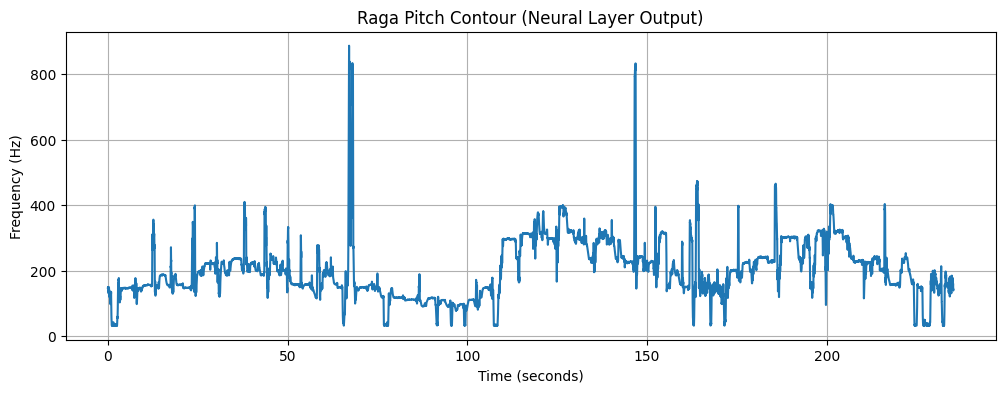

In [ ]:
import matplotlib.pyplot as plt

# Create a plot
plt.figure(figsize=(12, 4))
plt.plot(time, frequency, label='Raw Pitch')

# Labeling the graph
plt.xlabel('Time (seconds)')
plt.ylabel('Frequency (Hz)')
plt.title('Raga Pitch Contour (Neural Layer Output)')
plt.grid(True)
plt.show()

In [ ]:
!pip install whisper

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.8/42.8 kB 2.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for whisper: filename=whisper-1.1.10-py3-none-any.whl size=41120 sha256=0dce9bc9cf36ed73695ac2edd371aafbb1ced49f399947e46354ae3d370840a3
  Stored in directory: /root/.cache/pip/wheels/34/b8/4e/9c4c3351d670e06746a340fb4b7d854c76517eec225e5b32b1
Successfully built whisper


In [ ]:
!pip uninstall whisper

Found existing installation: whisper 1.1.10
Uninstalling whisper-1.1.10:
  Would remove:
    /usr/local/bin/find-corrupt-whisper-files.py
    /usr/local/bin/rrd2whisper.py
    /usr/local/bin/update-storage-times.py
    /usr/local/bin/whisper-auto-resize.py
    /usr/local/bin/whisper-auto-update.py
    /usr/local/bin/whisper-create.py
    /usr/local/bin/whisper-diff.py
    /usr/local/bin/whisper-dump.py
    /usr/local/bin/whisper-fetch.py
    /usr/local/bin/whisper-fill.py
    /usr/local/bin/whisper-info.py
    /usr/local/bin/whisper-merge.py
    /usr/local/bin/whisper-resize.py
    /usr/local/bin/whisper-set-aggregation-method.py
    /usr/local/bin/whisper-set-xfilesfactor.py
    /usr/local/bin/whisper-update.py
    /usr/local/lib/python3.12/dist-packages/whisper-1.1.10.dist-info/*
    /usr/local/lib/python3.12/dist-packages/whisper.py
Proceed (Y/n)? y
  Successfully uninstalled whisper-1.1.10


In [ ]:
!pip install openai-whisper

In [ ]:
import whisper
import json

# 1. Load the model (Only happens once)
model = whisper.load_model("small")

# 2. Transcribe the audio
# Note: Using your specific path /content/Bhairav_UP.wav
result = model.transcribe("/content/Bhairav_UP.wav")

# 3. Format the output for our "Scholar" logic layer
text_data = []
for segment in result['segments']:
    raw_text = segment['text'].strip()

    entry = {
        "start": round(segment['start'], 2),
        "end": round(segment['end'], 2),
        # 'unique_code' converts the Hindi into the \u0905 format for machine stability
        "unique_code": raw_text.encode('unicode-escape').decode('ascii'),
        # 'hindi_text' keeps the actual characters for musicological analysis
        "hindi_text": raw_text
    }
    text_data.append(entry)

# 4. Print the result
# ensure_ascii=False is critical here so 'hindi_text' renders correctly in your console
print(json.dumps(text_data, ensure_ascii=False, indent=2))

/usr/local/lib/python3.12/dist-packages/whisper/transcribe.py:132: UserWarning: FP16 is not supported on CPU; using FP32 instead
  warnings.warn("FP16 is not supported on CPU; using FP32 instead")


[
  {
    "start": 0.0,
    "end": 2.0,
    "unique_code": "\\u0905\\u0917\\u093c \\u092d\\u0942\\u0908\\u0930\\u0935",
    "hindi_text": "अग़ भूईरव"
  },
  {
    "start": 30.8,
    "end": 38.0,
    "unique_code": "\\u0930\\u0947\\u0928\\u093e\\u0935",
    "hindi_text": "रेनाव"
  },
  {
    "start": 38.5,
    "end": 43.6,
    "unique_code": "\\u0930\\u0947\\u0928",
    "hindi_text": "रेन"
  },
  {
    "start": 44.3,
    "end": 49.8,
    "unique_code": "\\u0930\\u0947\\u0902\\u0941",
    "hindi_text": "रेंु"
  },
  {
    "start": 50.3,
    "end": 53.5,
    "unique_code": "\\u0924\\u0926\\u093e\\u0935",
    "hindi_text": "तदाव"
  },
  {
    "start": 53.8,
    "end": 58.2,
    "unique_code": "\\u092e\\u0941\\u0930",
    "hindi_text": "मुर"
  },
  {
    "start": 59.0,
    "end": 65.0,
    "unique_code": "\\u0924\\u0926\\u093e\\u0935",
    "hindi_text": "तदाव"
  },
  {
    "start": 66.0,
    "end": 72.0,
    "unique_code": "\\u0928\\u093e\\u0935",
    "hindi_text": "नाव"
  },
  {
    "start

In [ ]:
with open("data.json","w") as f:
  json.dump(text_data,f)